# 分割实例与设计模型匹配审计（2026-09-12）

## tl;dr

- 最新 topology 运行在“匹配单元”口径下为 **210 / 210 一一映射**；70 / 70 个设计物理父件均有观测覆盖。数量匹配，但 topology 先验参与了实例整理，因此不是盲测精度。
- 长度：整体 210 个单元的平均绝对百分比误差（MAPE）为 **8.97%**；**193 / 210（91.9%）** 在 ±20% 内。直筋很好（MAPE 1.08%），短筋偏长明显（MAPE 34.90%），腹杆直段中等（MAPE 9.76%）。
- 拟合直径：**207 / 210** 在 0.01 mm 内等于设计直径；3 个异常（2 个 8→10 mm、1 个 6→4.876 mm）。但直径拟合会用 IFC 候选值做正则化，不能当作完全独立的实测验证。
- 拓扑：交叉高差/上下层序 **123 / 123** 通过 25 mm 规则；同父腹杆相邻段 **140 / 140** 在 100 mm 连接阈值内；平行关系 **578 / 654（88.4%）** 通过。76 个平行失败全部发生在“短筋 ↔ 直筋”相对位置，其他平行关系 100% 通过。
- 当前结果自带状态为 `requires_visual_review`；主要问题是短筋长度/位置与 16 个“横向包络过宽”实例，而不是数量或主网络拓扑。

## Context & Methods

### Key Assumptions

- “当前”指点云工作台 `latest.json` 指向的最新完整运行。
- 数量同时按 IFC 物理父件（physical bar）和算法可匹配单元（matching unit）报告。腹杆的折线父件按直段拆分后参与实例匹配。
- 长度主口径采用 `shapeReview.observedLengthM`（最终点云包络）对 `designLengthM`；同时检查实例摘要 `lengthM` 与该包络长度的一致性。
- 直径主口径采用实例 `diameterM` 对设计单元 `diameterM`；`observedWidthsM` 是最终点簇的横向包络，不等同于纯圆柱直径。
- 拓扑按设计关系去重后复算：parallel 使用相对横向位移容差 `max(25 mm, 40% × 设计间距)`；crossing 使用 25 mm 高差容差并检查上下层序；next 使用实例段端点最小距离，100 mm 是算法中的拓扑惩罚尺度。

### Sources

- `backend/data/assets/95b6b41c5857d9eb3407b155/pointcloud-steps/latest.json`
- 最新运行的 `manifest.json`、`complete-instances.json`、`positions.npy`、`complete_instance.npy`
- 运行内嵌的 IFC 设计 inventory（模型 `0910_YB-1.ifc`，BIM asset 7，alignment 2）


In [1]:
from pathlib import Path
from collections import Counter, defaultdict
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

pd.set_option("display.max_columns", 30)
plt.rcParams.update({"figure.figsize": (8.5, 4.5), "axes.grid": True, "grid.alpha": 0.25})

repo = Path.cwd().resolve()
while repo != repo.parent and not (repo / ".codegraph").exists():
    repo = repo.parent
run_root = repo / "backend/data/assets/95b6b41c5857d9eb3407b155/pointcloud-steps"
run_id = json.loads((run_root / "latest.json").read_text())["runId"]
run_dir = run_root / run_id
manifest = json.loads((run_dir / "manifest.json").read_text())
result = json.loads((run_dir / "complete-instances.json").read_text())
inventory = result["designReview"]["inventory"]
instances = result["instances"]
units = inventory["units"]
unit_by_id = {u["designUnitId"]: u for u in units}
instance_by_unit = {i["designUnitId"]: i for i in instances if i.get("designUnitId")}
print({"runId": run_id, "createdAtUTC": manifest["createdAt"], "priorMode": manifest["priorMode"],
       "sourcePoints": manifest["source"]["pointCount"], "model": result["designReview"]["modelInfo"]["name"]})

{'runId': '20260912T091923-1f27b275', 'createdAtUTC': '2026-09-12T09:20:04.662510+00:00', 'priorMode': 'topology', 'sourcePoints': 9216369, 'model': '0910_YB-1.ifc'}


## Data

### 1. Grain, coverage, and key integrity

In [2]:
coverage = inventory["coverage"]
design_parent_ids = {b["designBarId"] for b in inventory["bars"]}
observed_parent_ids = {i["designBarId"] for i in instances if i.get("designBarId")}
count_table = pd.DataFrame([
    ["设计物理父件", len(inventory["bars"]), len(observed_parent_ids), len(observed_parent_ids) / len(inventory["bars"])],
    ["设计匹配单元", len(units), len(instance_by_unit), len(instance_by_unit) / len(units)],
    ["最终分割实例", len(units), len(instances), len(instances) / len(units)],
], columns=["口径", "设计数", "已覆盖/观测数", "覆盖率"])
count_table["覆盖率"] = count_table["覆盖率"].map(lambda x: f"{x:.1%}")
display(count_table)

kind_count = pd.DataFrame([
    {"设计类型": kind, "设计单元": sum(u["kind"] == kind for u in units),
     "匹配实例": sum(unit_by_id[i["designUnitId"]]["kind"] == kind for i in instances)}
    for kind in ["straight", "short", "web"]
])
display(kind_count)

integrity = {
    "unique_instance_ids": len({i["id"] for i in instances}) == len(instances),
    "unique_design_unit_assignment": len(instance_by_unit) == len(instances),
    "unmatched_instances": sum(not i.get("designUnitId") for i in instances),
    "missing_shape_review": sum(not i.get("shapeReview") for i in instances),
    "missing_family": sum(i.get("family") is None for i in instances),
    "design_parents_covered": f"{len(observed_parent_ids)}/{len(design_parent_ids)}",
}
integrity

,口径,设计数,已覆盖/观测数,覆盖率
0,设计物理父件,70,70,100.0%
1,设计匹配单元,210,210,100.0%
2,最终分割实例,210,210,100.0%


,设计类型,设计单元,匹配实例
0,straight,54,54
1,short,12,12
2,web,144,144


{'unique_instance_ids': True,
 'unique_design_unit_assignment': True,
 'unmatched_instances': 0,
 'missing_shape_review': 0,
 'missing_family': 1,
 'design_parents_covered': '70/70'}

## Results

### 2. Length comparison

,n,design_sum_m,observed_sum_m,delta_sum_m,MAE_mm,MAPE_pct,median_APE_pct,P90_APE_pct,within_10pct,within_20pct
all,210.0,125.46,127.90,2.44,17.14,8.97,7.06,19.32,137.0,193.0
short,12.0,3.36,4.53,1.17,97.73,34.90,36.69,47.75,1.0,3.0
straight,54.0,107.16,107.16,0.00,17.96,1.08,0.33,2.05,53.0,54.0
web,144.0,14.95,16.21,1.27,10.12,9.76,8.72,19.01,83.0,136.0


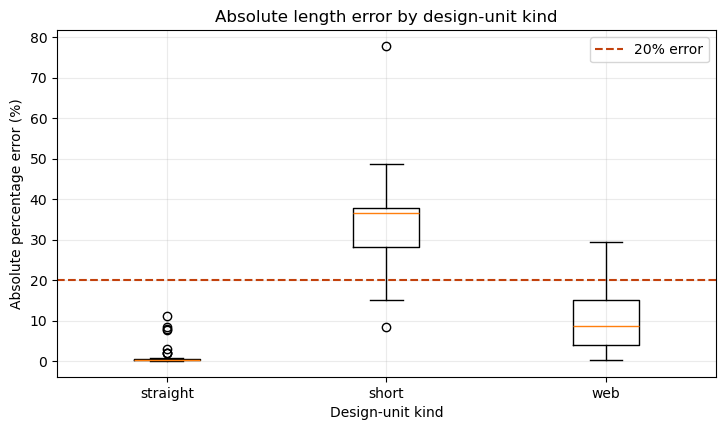

In [3]:
length_rows = []
for i in instances:
    review = i["shapeReview"]
    unit = unit_by_id[i["designUnitId"]]
    length_rows.append({
        "instanceId": i["id"], "kind": unit["kind"], "design_m": review["designLengthM"],
        "observed_m": review["observedLengthM"], "delta_mm": (review["observedLengthM"] - review["designLengthM"]) * 1000,
        "ape_pct": abs(review["lengthRatio"] - 1) * 100, "flags": ",".join(review["flags"]),
        "instance_length_m": i["lengthM"],
    })
length_df = pd.DataFrame(length_rows)

def length_summary(group):
    return pd.Series({
        "n": len(group), "design_sum_m": group.design_m.sum(), "observed_sum_m": group.observed_m.sum(),
        "delta_sum_m": (group.observed_m - group.design_m).sum(), "MAE_mm": group.delta_mm.abs().mean(),
        "MAPE_pct": group.ape_pct.mean(), "median_APE_pct": group.ape_pct.median(),
        "P90_APE_pct": group.ape_pct.quantile(.9), "within_10pct": (group.ape_pct <= 10).sum(),
        "within_20pct": (group.ape_pct <= 20).sum(),
    })
length_summary_table = pd.concat({"all": length_summary(length_df), **{
    kind: length_summary(group) for kind, group in length_df.groupby("kind")
}}, axis=1).T
for col in ["design_sum_m", "observed_sum_m", "delta_sum_m", "MAE_mm", "MAPE_pct", "median_APE_pct", "P90_APE_pct"]:
    length_summary_table[col] = length_summary_table[col].round(2)
display(length_summary_table)

fig, ax = plt.subplots()
order = ["straight", "short", "web"]
data = [length_df.loc[length_df.kind == k, "ape_pct"] for k in order]
ax.boxplot(data, tick_labels=order, showfliers=True)
ax.axhline(20, color="#c2410c", linestyle="--", linewidth=1.5, label="20% error")
ax.set(title="Absolute length error by design-unit kind", ylabel="Absolute percentage error (%)", xlabel="Design-unit kind")
ax.legend()
plt.show()

In [4]:
field_delta_mm = (length_df["instance_length_m"] - length_df["observed_m"]).abs() * 1000
field_check = pd.Series({
    "instance length vs point-envelope MAE (mm)": field_delta_mm.mean(),
    "median difference (mm)": field_delta_mm.median(),
    "P95 difference (mm)": field_delta_mm.quantile(.95),
    "difference > 5 mm": (field_delta_mm > 5).sum(),
    "difference > 20 mm": (field_delta_mm > 20).sum(),
    "max difference (mm)": field_delta_mm.max(),
}).round(2)
display(field_check.to_frame("value"))
display(length_df.assign(field_difference_mm=field_delta_mm)
        .nlargest(10, "field_difference_mm")[["instanceId", "kind", "instance_length_m", "observed_m", "field_difference_mm"]].round(4))

,value
instance length vs point-envelope MAE (mm),22.71
median difference (mm),9.14
P95 difference (mm),115.27
difference > 5 mm,156.00
difference > 20 mm,17.00
max difference (mm),303.16


,instanceId,kind,instance_length_m,observed_m,field_difference_mm
28,39,straight,3.8928,4.1960,303.1631
33,44,straight,3.8898,4.1920,302.1316
38,49,straight,3.8941,4.1947,300.6039
35,46,straight,3.8960,4.1945,298.5668
32,43,straight,3.8968,4.1944,297.6306
34,45,straight,3.8960,4.1925,296.5504
30,41,straight,3.9035,4.1947,291.1368
36,47,straight,3.8949,4.1855,290.5751
31,42,straight,3.9124,4.1783,265.9358
49,66,straight,1.0107,1.1544,143.6907


### 3. Diameter and transverse-envelope comparison

`diameterM` comes from cylinder fitting regularized to supported diameter modes; IFC diameters can supply those candidate modes when geometrically compatible. The “too wide” diagnostic below is independent final-cluster envelope evidence, but it includes any attached neighboring/fixture points and, for hooked bars, the designed hook envelope.

,design_mm,n,exact_0_01mm,within_0_5mm,MAE_mm,max_error_mm
0,6.0,144,143,143,0.008,1.124
1,8.0,66,64,64,0.061,2.000


,instanceId,kind,design_mm,observed_mm,abs_error_mm,shape_status,shape_flags
64,88,straight,8.0,10.000,2.000,consistent,
65,89,straight,8.0,10.000,2.000,consistent,
209,241,web,6.0,4.876,1.124,consistent,


shape_status,consistent,shape_mismatch,too_long,too_wide
kind,,,,
short,3,9,9,0
straight,38,16,0,16
web,144,0,0,0


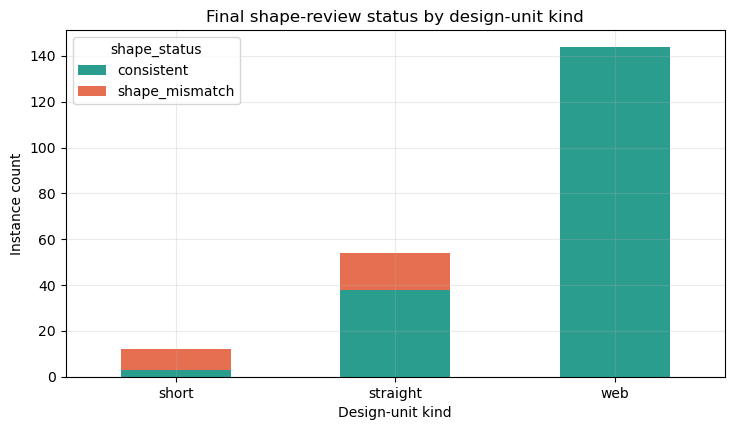

In [5]:
diameter_rows = []
for i in instances:
    unit = unit_by_id[i["designUnitId"]]
    diameter_rows.append({
        "instanceId": i["id"], "kind": unit["kind"], "design_mm": unit["diameterM"] * 1000,
        "observed_mm": i["diameterM"] * 1000,
        "abs_error_mm": abs(i["diameterM"] - unit["diameterM"]) * 1000,
        "shape_status": i["shapeReview"]["status"], "shape_flags": ",".join(i["shapeReview"]["flags"]),
    })
diameter_df = pd.DataFrame(diameter_rows)
diameter_summary = diameter_df.groupby("design_mm").agg(
    n=("instanceId", "size"), exact_0_01mm=("abs_error_mm", lambda s: (s <= .01).sum()),
    within_0_5mm=("abs_error_mm", lambda s: (s <= .5).sum()), MAE_mm=("abs_error_mm", "mean"),
    max_error_mm=("abs_error_mm", "max"),
).reset_index().round(3)
display(diameter_summary)
display(diameter_df.loc[diameter_df.abs_error_mm > .01].round(4))

shape_by_kind = pd.crosstab(diameter_df["kind"], diameter_df["shape_status"])
shape_by_kind["too_long"] = diameter_df.assign(too_long=diameter_df.shape_flags.str.contains("too_long")).groupby("kind").too_long.sum()
shape_by_kind["too_wide"] = diameter_df.assign(too_wide=diameter_df.shape_flags.str.contains("too_wide")).groupby("kind").too_wide.sum()
display(shape_by_kind)

fig, ax = plt.subplots()
shape_by_kind[[c for c in ["consistent", "shape_mismatch"] if c in shape_by_kind]].plot(kind="bar", stacked=True, ax=ax, color=["#2a9d8f", "#e76f51"])
ax.set(title="Final shape-review status by design-unit kind", xlabel="Design-unit kind", ylabel="Instance count")
ax.tick_params(axis="x", rotation=0)
plt.show()

### 4. Topology comparison

,kind,relations,passed,pass_rate,median_error_mm,P95_error_mm,max_error_mm
0,crossing,123,123,100.0,1.31,2.21,3.80
1,next,140,140,100.0,37.51,44.05,96.94
2,parallel,654,578,88.4,2.39,199.94,212.22


,pair,relations,passed,pass_rate,median_residual_mm,P95_residual_mm
0,short->short,8,8,100.0,5.67,17.89
1,short->straight,24,7,29.2,195.86,210.85
2,straight->short,79,20,25.3,192.77,209.43
3,straight->straight,216,216,100.0,4.55,15.38
4,web->web,327,327,100.0,0.96,12.13


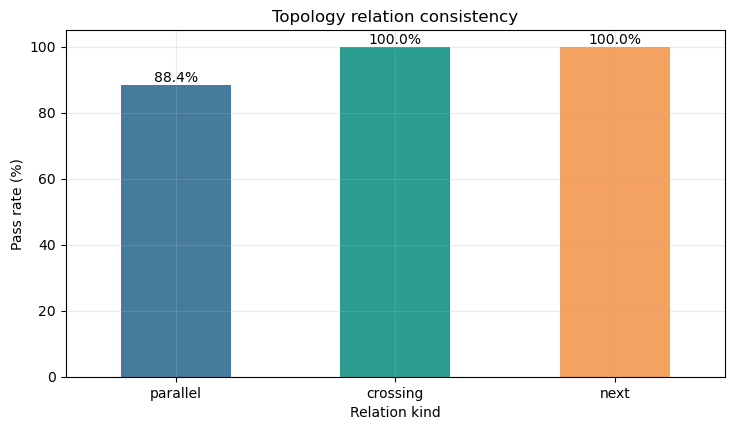

In [6]:
positions = np.load(run_dir / "positions.npy", mmap_mode="r")
owners = np.load(run_dir / "complete_instance.npy", mmap_mode="r")
max_id = int(owners.max())
owner_counts = np.bincount(owners, minlength=max_id + 1).astype(float)
centers = np.column_stack([
    np.bincount(owners, weights=positions[:, axis], minlength=max_id + 1) / np.maximum(owner_counts, 1)
    for axis in range(3)
])
segments_by_instance = defaultdict(list)
for segment in result["segments"]:
    segments_by_instance[int(segment["instanceId"])].append(segment)
instance_axes, instance_endpoints = {}, {}
for instance in instances:
    segs = segments_by_instance[instance["id"]]
    lengths = [np.linalg.norm(np.asarray(s["endM"]) - s["startM"]) for s in segs]
    longest = segs[int(np.argmax(lengths))]
    axis = np.asarray(longest["endM"]) - longest["startM"]
    instance_axes[instance["id"]] = axis / np.linalg.norm(axis)
    instance_endpoints[instance["id"]] = np.asarray([p for s in segs for p in (s["startM"], s["endM"])])

unique_relations = {}
for edge in inventory["relations"]:
    key = (edge["kind"], tuple(sorted((edge["from"], edge["to"]))))
    unique_relations.setdefault(key, edge)

topology_rows = []
parallel_detail = []
for (kind, _), edge in unique_relations.items():
    from_instance = instance_by_unit[edge["from"]]["id"]
    to_instance = instance_by_unit[edge["to"]]["id"]
    delta = centers[to_instance] - centers[from_instance]
    if kind == "parallel":
        axis = np.asarray(unit_by_id[edge["from"]]["direction"])
        transverse = delta - axis * (delta @ axis)
        expected = np.asarray(edge["offsetM"])
        residual_m = np.linalg.norm(transverse - expected)
        tolerance_m = max(.025, np.linalg.norm(expected) * .4)
        pair = f'{unit_by_id[edge["from"]]["kind"]}->{unit_by_id[edge["to"]]["kind"]}'
        passed = residual_m <= tolerance_m
        parallel_detail.append({"pair": pair, "passed": passed, "residual_mm": residual_m * 1000})
        topology_rows.append({"kind": kind, "passed": passed, "error_mm": residual_m * 1000})
    elif kind == "crossing":
        error_m = abs(delta[2] - edge["heightDifferenceM"])
        topology_rows.append({"kind": kind, "passed": error_m <= .025, "error_mm": error_m * 1000})
    elif kind == "next":
        gap_m = np.min(np.linalg.norm(
            instance_endpoints[from_instance][:, None, :] - instance_endpoints[to_instance][None, :, :], axis=2))
        topology_rows.append({"kind": kind, "passed": gap_m <= .1, "error_mm": gap_m * 1000})

topology_df = pd.DataFrame(topology_rows)
topology_summary = topology_df.groupby("kind").agg(
    relations=("passed", "size"), passed=("passed", "sum"), pass_rate=("passed", "mean"),
    median_error_mm=("error_mm", "median"), P95_error_mm=("error_mm", lambda s: s.quantile(.95)),
    max_error_mm=("error_mm", "max"),
).reset_index()
topology_summary["pass_rate"] = (topology_summary["pass_rate"] * 100).round(1)
display(topology_summary.round(2))

parallel_df = pd.DataFrame(parallel_detail)
parallel_breakdown = parallel_df.groupby("pair").agg(
    relations=("passed", "size"), passed=("passed", "sum"), pass_rate=("passed", "mean"),
    median_residual_mm=("residual_mm", "median"), P95_residual_mm=("residual_mm", lambda s: s.quantile(.95)),
).reset_index()
parallel_breakdown["pass_rate"] = (parallel_breakdown["pass_rate"] * 100).round(1)
display(parallel_breakdown.round(2))

fig, ax = plt.subplots()
plot = topology_summary.set_index("kind")["pass_rate"].reindex(["parallel", "crossing", "next"])
plot.plot(kind="bar", ax=ax, color=["#457b9d", "#2a9d8f", "#f4a261"])
ax.set(title="Topology relation consistency", xlabel="Relation kind", ylabel="Pass rate (%)", ylim=(0, 105))
ax.set_xticks(range(len(plot)), labels=plot.index, rotation=0)
for idx, value in enumerate(plot): ax.text(idx, value + 1, f"{value:.1f}%", ha="center")
plt.show()

## Takeaways

1. **数量/ID 匹配通过，但不是独立盲测。** 210 个最终实例与 210 个设计匹配单元形成无缺失、无重复的一一映射；70 个设计父件全部有覆盖。该运行由 237 个初始实例经 topology 设计辅助整理到 210 个（7 次合并、29 个新实例化），所以精确数量包含先验约束效果。
2. **直筋长度可信，短筋是主要长度问题。** 直筋 54 个 MAPE 1.08%；腹杆直段 144 个 MAPE 9.76%；短筋 12 个 MAPE 34.90%，其中 9 个被标记 `too_long`。整体 193 / 210 在 ±20% 内。
3. **拟合直径表面上高度一致，独立性有限。** 207 / 210 在 0.01 mm 内吻合；异常为实例 88、89（设计 8 mm、拟合 10 mm）和实例 241（设计 6 mm、拟合约 4.876 mm）。同时有 16 个直筋点簇横向包络过宽，提示邻筋/夹具残留或实例归属过宽。
4. **主网络拓扑基本正确，短筋相对位置不稳。** crossing 和 next 全部通过当前规则；所有 web↔web、straight↔straight、short↔short 平行关系也通过。76 个平行失败全部来自 short↔straight，和短筋长度偏长指向同一局部问题。
5. **字段口径存在内部不一致。** 实例摘要 `lengthM` 与最终点簇包络长度在 156 / 210 个实例上相差超过 5 mm，17 个超过 20 mm，最大约 303 mm；下游展示/验收应统一长度口径。